In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity


In [9]:
# loading the dataset
movie=pd.read_csv("indian_movies.csv")
movie

,title,genres,director,cast,rating,year
0,3 Idiots,Comedy Drama,Rajkumar Hirani,Aamir Khan R. Madhavan Sharman Joshi,8.4,2009
1,Dangal,Biography Drama,Siddharth Anand,Aamir Khan Fatima Sana Shaikh,8.3,2016
2,PK,Comedy Drama,S. S. Rajamouli,Aamir Khan Anushka Sharma,8.1,2014
3,Lagaan,Drama Sport,Ashutosh Gowariker,Aamir Khan Gracy Singh,8.1,2001
4,Taare Zameen Par,Drama Family,Aamir Khan,Aamir Khan Darsheel Safary,8.4,2007
5,Baahubali: The Beginning,Action Drama,S. S. Rajamouli,Prabhas Rana Daggubati,8.0,2015
6,Baahubali 2: The Conclusion,Action Drama,S. S. Rajamouli,Prabhas Anushka Shetty,8.2,2017
7,RRR,Action Drama,S. S. Rajamouli,Ram Charan N. T. Rama Rao Jr.,8.0,2022
8,Chennai Express,Comedy Romance,Rohit Shetty,Shah Rukh Khan Deepika Padukone,6.9,2013
9,Dilwale Dulhania Le Jayenge,Romance Drama,Aditya Chopra,Shah Rukh Khan Kajol,8.0,1995


In [10]:
# data cleaning
movies=movie[['title','genres','director','cast','rating','year']]
movies.dropna(inplace=True)

Text(0, 0.5, 'count')

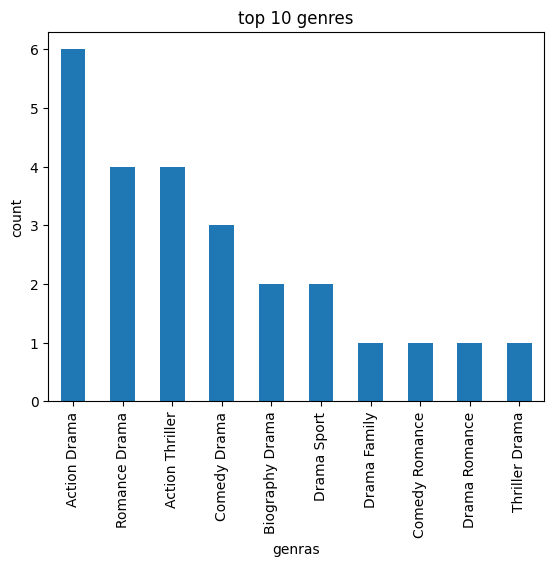

In [11]:
plt.figure()
movies['genres'].value_counts().head(10).plot(kind='bar')
plt.title("top 10 genres")
plt.xlabel("genras")
plt.ylabel("count")


Text(0.5, 1.0, 'rating distrubition')

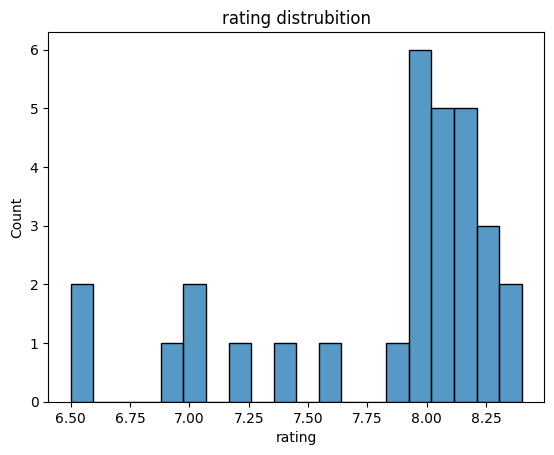

In [12]:
# ratings distribution in histogram
plt.Figure()
sns.histplot(movies['rating'],bins=20)
plt.title("rating distrubition")

<Axes: xlabel='year'>

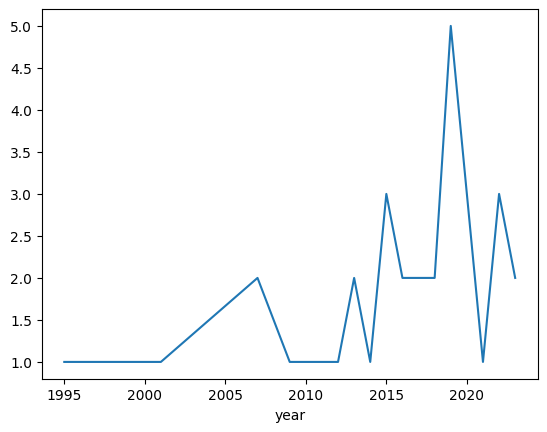

In [13]:
# movies per year
plt.Figure()
movies['year'].value_counts().sort_index().plot()

In [14]:
movies['combined']=movies['genres']+""+movies['director']+""+movies['cast'] # here we combined multiple catorgies into one variable
movies['combined']

0     Comedy Drama Rajkumar HiraniAamir Khan R. Madh...
1     Biography DramaSiddharth AnandAamir Khan Fatim...
2     Comedy DramaS. S. RajamouliAamir Khan Anushka ...
3     Drama SportAshutosh GowarikerAamir Khan Gracy ...
4      Drama FamilyAamir KhanAamir Khan Darsheel Safary
5     Action DramaS. S. RajamouliPrabhas Rana Daggubati
6     Action DramaS. S. RajamouliPrabhas Anushka Shetty
7     Action DramaS. S. RajamouliRam Charan N. T. Ra...
8     Comedy RomanceRohit ShettyShah Rukh Khan Deepi...
9        Romance DramaAditya ChopraShah Rukh Khan Kajol
10         Drama RomanceKaran JoharShah Rukh Khan Kajol
11    Action ThrillerSiddharth AnandShah Rukh Khan D...
12    Romance DramaSandeep Reddy VangaShahid Kapoor ...
13      Action DramaSukumarAllu Arjun Rashmika Mandanna
14    Romance DramaSandeep Reddy VangaVijay Deverako...
15         Thriller DramaNishikant KamatAjay Devgn Tabu
16    Thriller CrimeSriram RaghavanAyushmann Khurran...
17    Comedy HorrorPriyadarshanAkshay Kumar Vidy

In [15]:
# converting into numeric form
tfdif=TfidfVectorizer(stop_words='english')
tfidix_vector=tfdif.fit_transform(movies['combined'])


In [16]:
# calculating cosine simalarity
similarity=cosine_similarity(tfidix_vector)
similarity

array([[1.        , 0.04438479, 0.15915721, 0.12726953, 0.12444293,
        0.        , 0.        , 0.        , 0.13971088, 0.05330062,
        0.13388126, 0.0514044 , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.09471735, 0.        , 0.        ,
        0.        , 0.        , 0.11874473, 0.12918299, 0.        ,
        0.        , 0.        , 0.08905805, 0.        , 0.07002041],
       [0.04438479, 1.        , 0.05654692, 0.05217472, 0.05101594,
        0.        , 0.        , 0.        , 0.04963784, 0.05373849,
        0.05488523, 0.05182669, 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.04867994, 0.05295915, 0.        ,
        0.13908964, 0.        , 0.        , 0.        , 0.        ],
       [0.15915721, 0.05654692, 1.        , 0.06592978, 0.06446552,
        0.15286045, 0.35837692, 0.12292928, 0.17799383, 0.06790582,
        0.06935488, 0.06549   , 0.        , 0.

In [19]:
def recommend(movie_name,top_n=5):
    if movie_name not in movies['title'].values:
        print("movie not found in dataset")
        return
    index=movies[movies['title']==movie_name].index[0]
    distance=list(enumerate(similarity[index]))
    shorted_movies=sorted(distance,key=lambda x:x[1],reverse=True)[1:top_n+1]
    print(f"Top {top_n} movies similar to '{movie_name}':\n")
    for i in shorted_movies:
        print(".....",movies.iloc[i[0]].title)
recommend("3 Idiots")

Top 5 movies similar to '3 Idiots':

..... PK
..... Chennai Express
..... My Name Is Khan
..... Bajrangi Bhaijaan
..... Lagaan
